# TeleGuard — Notebook 01: Exploratory Data Analysis (EDA)

**Project:** TeleGuard — GAN-augmented telecom network anomaly detection.

**Purpose of this notebook.** Before writing any machine-learning code, we first *understand the data*. This is the **Exploratory Data Analysis (EDA)** stage — we load the raw NSL-KDD dataset, inspect its structure, look at the attack types, and measure the **class balance** between normal and anomalous connections.

**Where this fits in the pipeline.** The TeleGuard pipeline has five stages, written as `.py` modules in `src/` and `app/`. This notebook is the *experiment / exploration* step that comes **before** Stage 1 (preprocessing) — its job is to justify the design decisions made later (why we scale features, why we use a GAN, and how we frame the problem).

| Step | What we learn |
|---|---|
| 1. Load the raw data | The 41 features + label + difficulty structure |
| 2. `describe()` | Feature value ranges (→ motivates scaling) |
| 3. `value_counts()` on the label | The many attack types, and which are rare |
| 4. Binary target | The normal-vs-anomaly balance (a key finding) |
| 5. Visualisation | A saved class-balance chart used in the report & dashboard |

> **Before running:** make sure `KDDTrain+.txt` is in `data/raw/` (NSL-KDD, Kaggle dataset `hassan06/nslkdd`). This notebook reuses functions from `src/preprocessing.py` so the exploration matches exactly how the production pipeline reads the data.

## Setup and imports

We add the project root to the path so we can import the shared preprocessing helpers, then configure plotting. `PROJECT_ROOT` points to the `teleguard/` folder whether the notebook is run from `notebooks/` or the project root.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project root importable so we can reuse src/preprocessing.py
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    COLUMN_NAMES,
    LABEL_COL,
    load_raw,
    make_binary_target,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "KDDTrain+.txt"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print("Raw data path:", RAW_PATH)

Raw data path: D:\gan\teleguard\data\raw\KDDTrain+.txt


## Step 1: Load the raw data

NSL-KDD files have **no header row**. Each line has **43 comma-separated values**: 41 input features, the attack `label`, and a `difficulty` score. We use the standard NSL-KDD column names (defined once in `src/preprocessing.py` as `COLUMN_NAMES`) so the columns are labelled correctly.

Three of the features are **categorical** (text): `protocol_type` (e.g. tcp/udp/icmp), `service` (e.g. http, private), and `flag` (e.g. SF, REJ). The rest are numeric counts and rates.

In [2]:
# Load with the standard 43 NSL-KDD column names (41 features + label + difficulty)
df = load_raw(RAW_PATH)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


**What to notice in `head()`:** every row is one network connection. The categorical columns (`protocol_type`, `service`, `flag`) hold text, while columns like `src_bytes`, `dst_bytes`, and `count` hold very different numeric ranges. The final `label` column names the attack (or `normal`).

## Step 2: Summary statistics

`describe()` shows the range of each numeric feature. The key observation is that the features live on **wildly different scales** — for example `src_bytes` can be in the millions while rate features sit between 0 and 1. A model could be biased toward the large-magnitude columns, which is exactly why **Stage 1 preprocessing min-max scales every numeric feature to [0, 1]**.

In [3]:
# Summary statistics for the numeric columns
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


## Step 3: Attack types (multi-class view)

The raw `label` column names the specific attack. Counting them reveals two things: (1) there are *many* distinct attack types, and (2) they are **very unevenly distributed**. Common attacks such as `neptune` and `smurf` have tens of thousands of records, while rare attacks in the **U2R** (User-to-Root, ~52 records) and **R2L** (Remote-to-Local, ~995 records) families are extremely scarce.

This *attack-category* rarity — not the binary balance below — is where data augmentation has the most potential to help.

In [4]:
# How many of each attack type? (multi-class view of the raw label)
df[LABEL_COL].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

## Step 4: The binary target — normal vs anomaly

The project frames detection as a **binary** problem: `normal` -> 0, every attack -> 1. We use the same `make_binary_target()` helper the pipeline uses, then print the balance.

**This is one of the most important results in the whole project.** At the binary level the dataset is *already roughly balanced* (about 53% normal to 47% anomaly). That means there is no severe class imbalance to fix here — a finding that directly explains why GAN class-balancing gives little benefit in the binary A/B experiment (Phase 3).

In [5]:
# Collapse to the binary target: normal (0) vs anomaly (1)
df = make_binary_target(df)
class_counts = df["target"].value_counts().sort_index()
class_counts.index = ["normal (0)", "anomaly (1)"]

total = len(df)
for name, count in class_counts.items():
    print(f"{name:>12}: {count:>8,}  ({100 * count / total:5.2f}%)")

  normal (0):   67,343  (53.46%)
 anomaly (1):   58,630  (46.54%)


## Step 5: Visualise the class balance

Finally we draw a bar chart of the normal-vs-anomaly counts and save it to `reports/figures/class_imbalance.png`. This saved figure is reused in the final report and embedded in the Streamlit dashboard's **Experiment Results** tab — so the EDA done here feeds directly into the deliverables.

Saved figure -> D:\gan\teleguard\reports\figures\class_imbalance.png


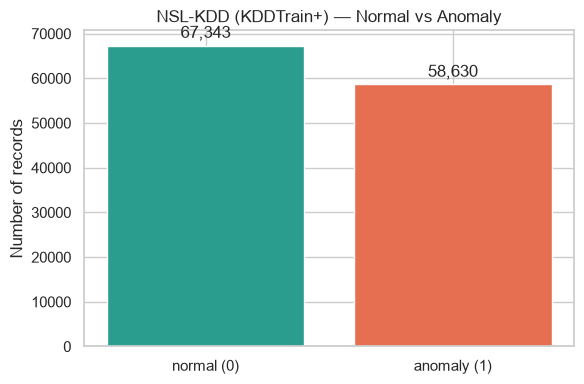

In [6]:
# Bar chart of the class balance -> save to reports/figures/
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#2a9d8f", "#e76f51"]
bars = ax.bar(class_counts.index, class_counts.values, color=colors)

ax.set_title("NSL-KDD (KDDTrain+) — Normal vs Anomaly")
ax.set_ylabel("Number of records")
ax.bar_label(bars, fmt="{:,.0f}", padding=3)

fig.tight_layout()
out_path = FIG_DIR / "class_imbalance.png"
fig.savefig(out_path, dpi=150)
print("Saved figure ->", out_path)
plt.show()

## Key takeaways

1. **Structure.** NSL-KDD has 41 features (3 categorical, the rest numeric) plus an attack label — confirming the need for categorical encoding and numeric scaling in Stage 1.
2. **Feature scales differ hugely** -> we min-max scale everything to [0, 1] in preprocessing.
3. **Binary classes are already ~balanced (~53% / ~47%)** -> there is no strong imbalance at the normal-vs-anomaly level, which is exactly why the GAN-augmented model does **not** beat the baseline in the binary A/B test.
4. **The real rarity is at the attack-category level** (U2R, R2L) -> this is the most promising direction for GAN augmentation and is identified as future work.

These insights motivate every later phase: preprocessing (Stage 1), CTGAN synthetic-data generation (Stage 2), the A/B classifier experiment (Stage 3), LLM explanations (Stage 4), and the dashboard (Stage 5).